# A-level sciences: Physics, Chemistry and Biology against GCSE science

The same question as for English, now with three A-level subjects. We model A-level Physics, Chemistry and Biology value added together against GCSE science value added (`SCIVAMEA_PTQ_EE`, the science element of the GCSE value-added measure).

As for English Language and Literature, the model has:

- a latent school-level **GCSE science VA**, measured with known error;
- **subject-specific** intercept and slope on that GCSE VA;
- **correlated school residuals** across the three subjects: after accounting for GCSE, a school that does unusually well in Physics may also do unusually well in Chemistry and Biology. With three subjects the correlations form a matrix, with an LKJ prior.

A more complex model with an explicit shared school effect could not be fitted for English, because the shared effect was not identifiable for schools with only one subject. Here 1,142 of 1,636 schools have all three subjects, so it may be workable, but we first look at the results of this model.

In [1]:
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt

%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v6.3.1


## Data

We reshape `all-value-add-errors.csv` to long format: one row per school × subject, keeping the published confidence interval and entries. Schools need GCSE science VA and at least one of the three A-level VA scores. The standard error is `(upper - lower) / (2 * 1.96)`.

In [2]:
raw = pd.read_csv("data/all-value-add-errors.csv")

subjects = ["Physics", "Chemistry", "Biology"]
school_cols = ["URN", "SCIVAMEA_PTQ_EE", "SCIVAMEA_PTQ_EE lower", "SCIVAMEA_PTQ_EE upper", "SCIVAMEA_PTQ_EE pupils"]

schools = (
    raw[school_cols]
    .rename(columns={"SCIVAMEA_PTQ_EE": "gcse_va", "SCIVAMEA_PTQ_EE lower": "gcse_lower",
                     "SCIVAMEA_PTQ_EE upper": "gcse_upper", "SCIVAMEA_PTQ_EE pupils": "gcse_pupils"})
    .dropna()
)

frames = []
for subject in subjects:
    prefix = f"A-level {subject}"
    sub = raw[["URN", f"{prefix} VA", f"{prefix} VA lower", f"{prefix} VA upper", f"{prefix} entries"]].dropna()
    sub.columns = ["URN", "alevel_va", "alevel_lower", "alevel_upper", "alevel_entries"]
    sub["subject"] = subject
    frames.append(sub)
long = pd.concat(frames)

Z_95 = 1.96
long["alevel_se"] = (long["alevel_upper"] - long["alevel_lower"]) / (2 * Z_95)
schools["gcse_se"] = (schools["gcse_upper"] - schools["gcse_lower"]) / (2 * Z_95)

long = long.merge(schools[["URN"]], on="URN", how="inner")
schools = schools[schools["URN"].isin(long["URN"])].reset_index(drop=True)

school_idx = pd.Series(np.arange(len(schools)), index=schools["URN"])
long["school_idx"] = long["URN"].map(school_idx).to_numpy()
long["subject_idx"] = long["subject"].map({s: k for k, s in enumerate(subjects)}).to_numpy()
long = long.reset_index(drop=True)

print(f"{len(schools)} schools, {len(long)} school-subject observations")
print("subjects per school:", long.groupby("URN")["subject"].nunique().value_counts().sort_index().to_dict())
long.groupby("subject")[["alevel_va", "alevel_se", "alevel_entries"]].agg(["mean", "std", "median"]).round(3)

1636 schools, 4252 school-subject observations
subjects per school: {1: 162, 2: 332, 3: 1142}


alevel_va               alevel_se               alevel_entries  \
               mean    std median      mean    std median           mean   
subject                                                                    
Biology      -0.061  0.422  -0.03     0.261  0.083  0.253         23.473   
Chemistry    -0.088  0.493  -0.07     0.296  0.096  0.296         22.294   
Physics      -0.078  0.503  -0.05     0.324  0.094  0.327         18.030   

                          
              std median  
subject                   
Biology    17.647   18.0  
Chemistry  19.658   15.0  
Physics    13.720   13.0

### Checking the confidence-interval formula

DfE's interval is $\pm 1.96\,\sigma_{national}/\sqrt{n}$, so $se\sqrt{n}$ should be constant within each measure.

In [3]:
print((long["alevel_se"] * np.sqrt(long["alevel_entries"])).groupby(long["subject"]).agg(["mean", "std"]).round(3))
print("GCSE science:", (schools["gcse_se"] * np.sqrt(schools["gcse_pupils"])).agg(["mean", "std"]).round(3).to_dict())

            mean    std
subject                
Biology    1.068  0.005
Chemistry  1.147  0.005
Physics    1.181  0.005
GCSE science: {'mean': 1.457, 'std': 0.014}


Each measure has its own near-constant national SD, so the standard errors are pure sampling noise.

## Exploratory look

Left: each subject against GCSE science VA. Right: for schools with all three subjects, the raw correlations between the A-level VA scores.

/tmp/ipykernel_103503/1932097169.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


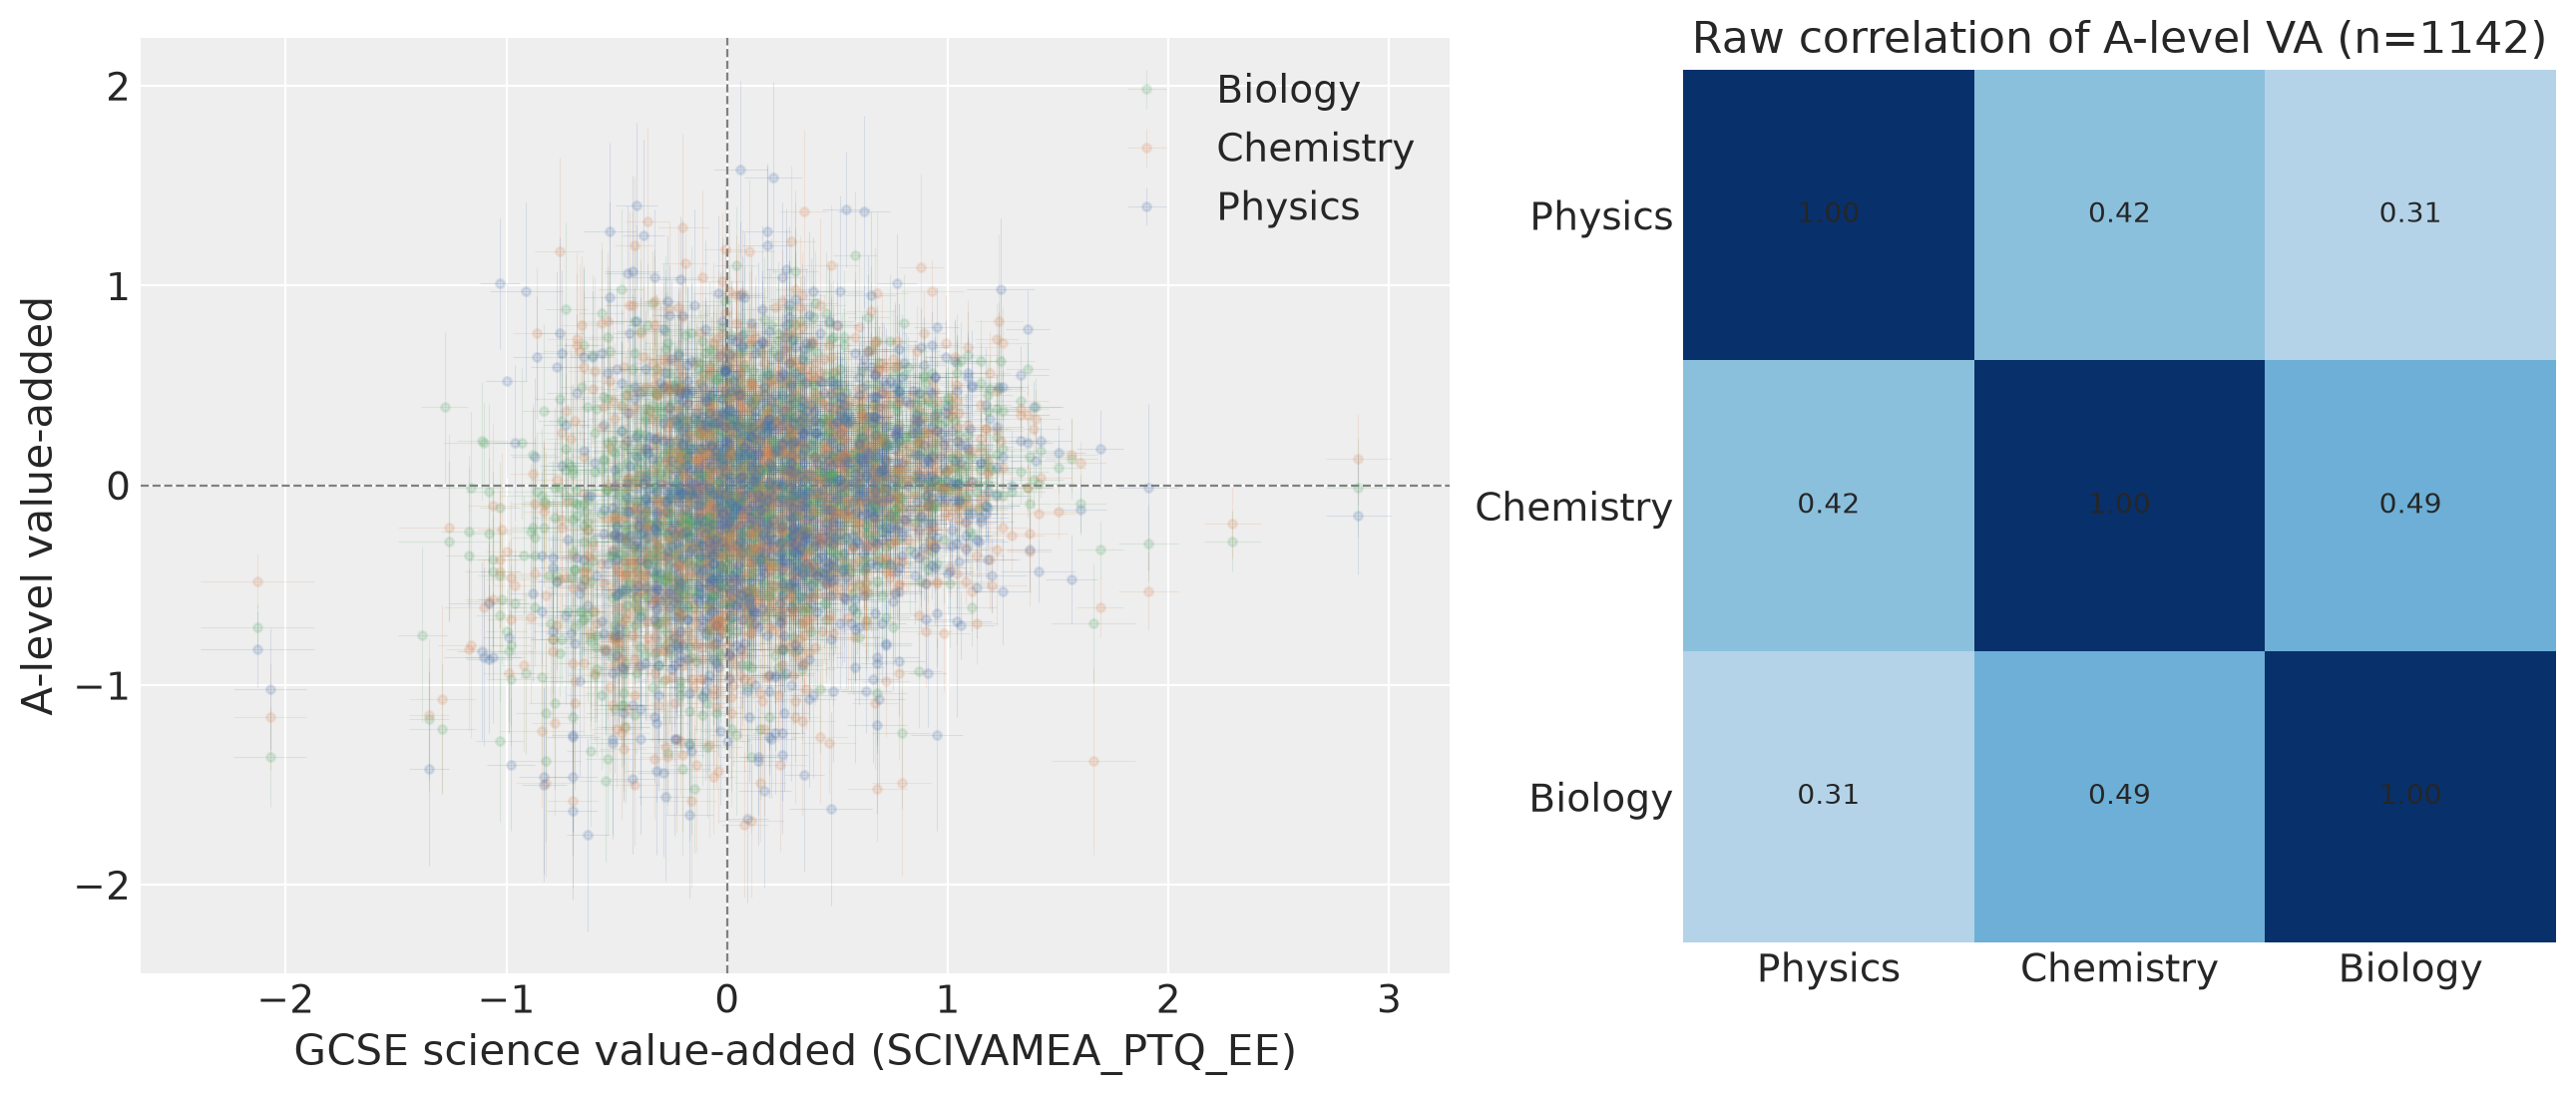

In [4]:
colors = {"Physics": "#4C72B0", "Chemistry": "#DD8452", "Biology": "#55A868"}
plot_df = long.merge(schools[["URN", "gcse_va", "gcse_se"]], on="URN")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [1.5, 1]})
for subject, g in plot_df.groupby("subject"):
    axes[0].errorbar(g["gcse_va"], g["alevel_va"], xerr=g["gcse_se"], yerr=g["alevel_se"], fmt="o",
                     color=colors[subject], ecolor=colors[subject], alpha=0.15, markersize=3, elinewidth=0.4, label=subject)
axes[0].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[0].axvline(0, color="grey", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("GCSE science value-added (SCIVAMEA_PTQ_EE)")
axes[0].set_ylabel("A-level value-added")
axes[0].legend()

wide = long.pivot(index="URN", columns="subject", values="alevel_va")[subjects].dropna()
raw_corr = wide.corr()
im = axes[1].imshow(raw_corr, vmin=0, vmax=1, cmap="Blues")
axes[1].set_xticks(range(3), subjects)
axes[1].set_yticks(range(3), subjects)
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f"{raw_corr.iloc[i, j]:.2f}", ha="center", va="center")
axes[1].set_title(f"Raw correlation of A-level VA (n={len(wide)})")
axes[1].grid(False)
plt.tight_layout()
plt.show()

The raw correlations between subjects are noticeably higher than for English Language and Literature. They are still attenuated by sampling noise in each score, which the model handles.

## Model

For school $i$ with true GCSE VA $x_i$, and subject $s \in \{\text{Physics}, \text{Chemistry}, \text{Biology}\}$:

$$
\begin{aligned}
x_i &\sim \text{Normal}(\mu_x, \tau_x), \qquad x_i^{obs} \sim \text{Normal}(x_i, \sigma^x_i) \\
y_{is} &= \alpha_s + \beta_s x_i + \epsilon_{is}, \qquad y_{is}^{obs} \sim \text{Normal}(y_{is}, \sigma^y_{is}) \\
\boldsymbol{\epsilon}_i &\sim \text{MultivariateNormal}(0, \Sigma), \qquad \Sigma = \text{diag}(\tau)\, R\, \text{diag}(\tau), \quad R \sim \text{LKJ}(\eta = 2)
\end{aligned}
$$

$R$ is the $3\times3$ correlation matrix of a school's true subject effects once the GCSE effect is removed. Schools with fewer than three subjects contribute through the marginal distribution of the subjects they have. Each subject's $\alpha_s, \beta_s$ gets its own weakly informative prior. The residuals are non-centered via the Cholesky factor of $\Sigma$.

In [5]:
n_schools = len(schools)
gcse_obs = schools["gcse_va"].to_numpy()
gcse_se = schools["gcse_se"].to_numpy()
y_obs = long["alevel_va"].to_numpy()
y_se = long["alevel_se"].to_numpy()
s_idx = long["school_idx"].to_numpy()
subj_idx = long["subject_idx"].to_numpy()
n_subjects = len(subjects)

with pm.Model(coords={"subject": subjects}) as corr_model:
    mu_x = pm.Normal("mu_x", 0, 1)
    tau_x = pm.HalfNormal("tau_x", 1)
    x_raw = pm.Normal("x_raw", 0, 1, shape=n_schools)
    x_true = mu_x + tau_x * x_raw

    alpha = pm.Normal("alpha", 0, 1, dims="subject")
    beta = pm.Normal("beta", 0, 1, dims="subject")

    chol, corr, stds = pm.LKJCholeskyCov(
        "chol_cov", n=n_subjects, eta=2.0, sd_dist=pm.HalfNormal.dist(1.0, shape=n_subjects), compute_corr=True
    )
    z = pm.Normal("z", 0, 1, shape=(n_schools, n_subjects))
    eps_all = pt.dot(z, chol.T)
    eps = eps_all[s_idx, subj_idx]

    y_true = alpha[subj_idx] + beta[subj_idx] * x_true[s_idx] + eps

    pm.Normal("gcse_obs", mu=x_true, sigma=gcse_se, observed=gcse_obs)
    pm.Normal("alevel_obs", mu=y_true, sigma=y_se, observed=y_obs)

### Prior predictive check

Sampling: [alevel_obs, alpha, beta, chol_cov, gcse_obs, mu_x, tau_x, x_raw, z]


/tmp/ipykernel_103503/6268304.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


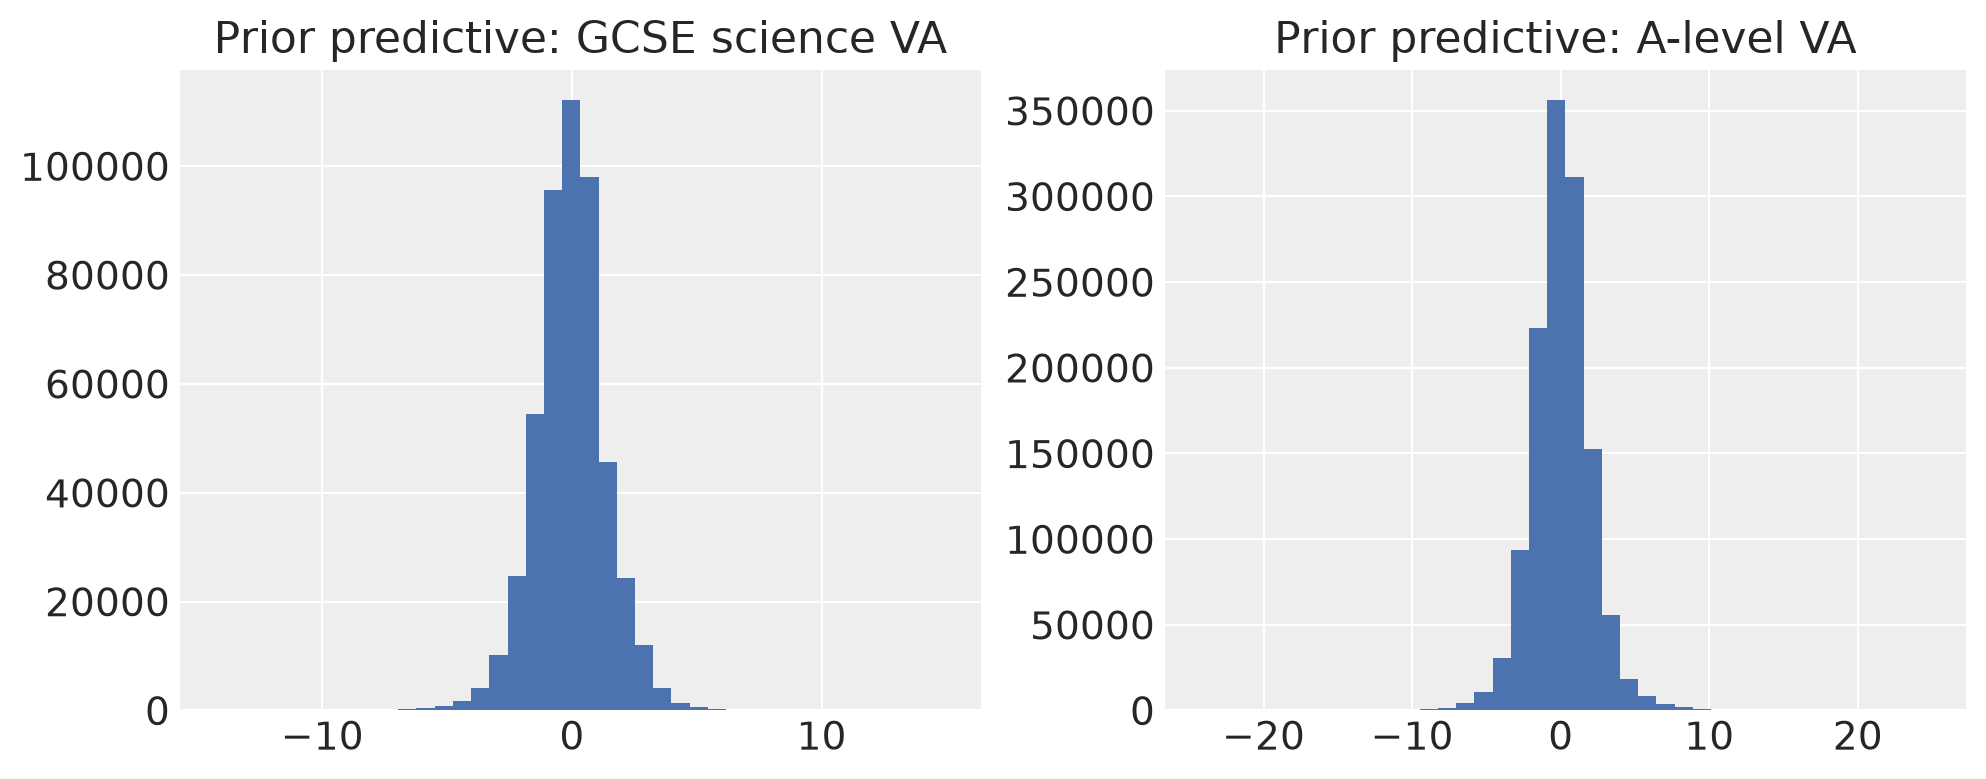

In [6]:
with corr_model:
    prior = pm.sample_prior_predictive(draws=300, random_seed=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(prior.prior_predictive["gcse_obs"].to_numpy().ravel(), bins=40, color="#4C72B0")
axes[0].set_title("Prior predictive: GCSE science VA")
axes[1].hist(prior.prior_predictive["alevel_obs"].to_numpy().ravel(), bins=40, color="#4C72B0")
axes[1].set_title("Prior predictive: A-level VA")
plt.tight_layout()
plt.show()
del prior

### Fit

In [7]:
with corr_model:
    idata_corr = pm.sample(draws=1000, tune=2000, chains=4, target_accept=0.99,
                           random_seed=RANDOM_SEED, progressbar=False)
    idata_corr.update(pm.sample_posterior_predictive(idata_corr, random_seed=RANDOM_SEED, progressbar=False))

NUTS[nutpie]: [mu_x, tau_x, x_raw, alpha, beta, chol_cov, z]


Sampling: [alevel_obs, gcse_obs]


### Diagnostics

In [8]:
print(f"divergences = {int(idata_corr.sample_stats['diverging'].sum())}")
az.summary(idata_corr, var_names=["alpha", "beta", "chol_cov_stds", "chol_cov_corr", "mu_x", "tau_x"], round_to=3)

divergences = 0


/opt/conda/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/conda/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha[Physics],-0.132,0.015,-0.156,-0.108,2256.580,2730.289,1.001,0.000,0.000
alpha[Chemistry],-0.140,0.013,-0.162,-0.119,1736.722,2237.274,1.002,0.000,0.000
alpha[Biology],-0.091,0.010,-0.108,-0.074,2168.421,2671.627,1.002,0.000,0.000
beta[Physics],0.205,0.027,0.162,0.250,1500.840,2220.942,1.002,0.001,0.000
beta[Chemistry],0.233,0.025,0.193,0.273,1349.791,1965.827,1.002,0.001,0.000
beta[Biology],0.225,0.020,0.194,0.257,1724.661,2341.531,1.002,0.000,0.000
chol_cov_stds[0],0.340,0.013,0.319,0.360,2189.724,2382.843,1.002,0.000,0.000
chol_cov_stds[1],0.362,0.011,0.345,0.380,1830.851,2406.932,1.001,0.000,0.000
chol_cov_stds[2],0.285,0.009,0.270,0.300,2104.521,2515.937,1.003,0.000,0.000
"chol_cov_corr[0, 0]",1.000,0.000,1.000,1.000,4000.000,4000.000,NaN,0.000,NaN


## What the pooling shows

### How related are a school's effects across the three sciences?

Posterior of the three pairwise correlations between a school's true subject effects, after removing the GCSE effect.

Physics-Chemistry  mean=0.763, 89% interval [0.709, 0.813]
Physics-Biology    mean=0.592, 89% interval [0.524, 0.657]
Chemistry-Biology    mean=0.839, 89% interval [0.799, 0.877]


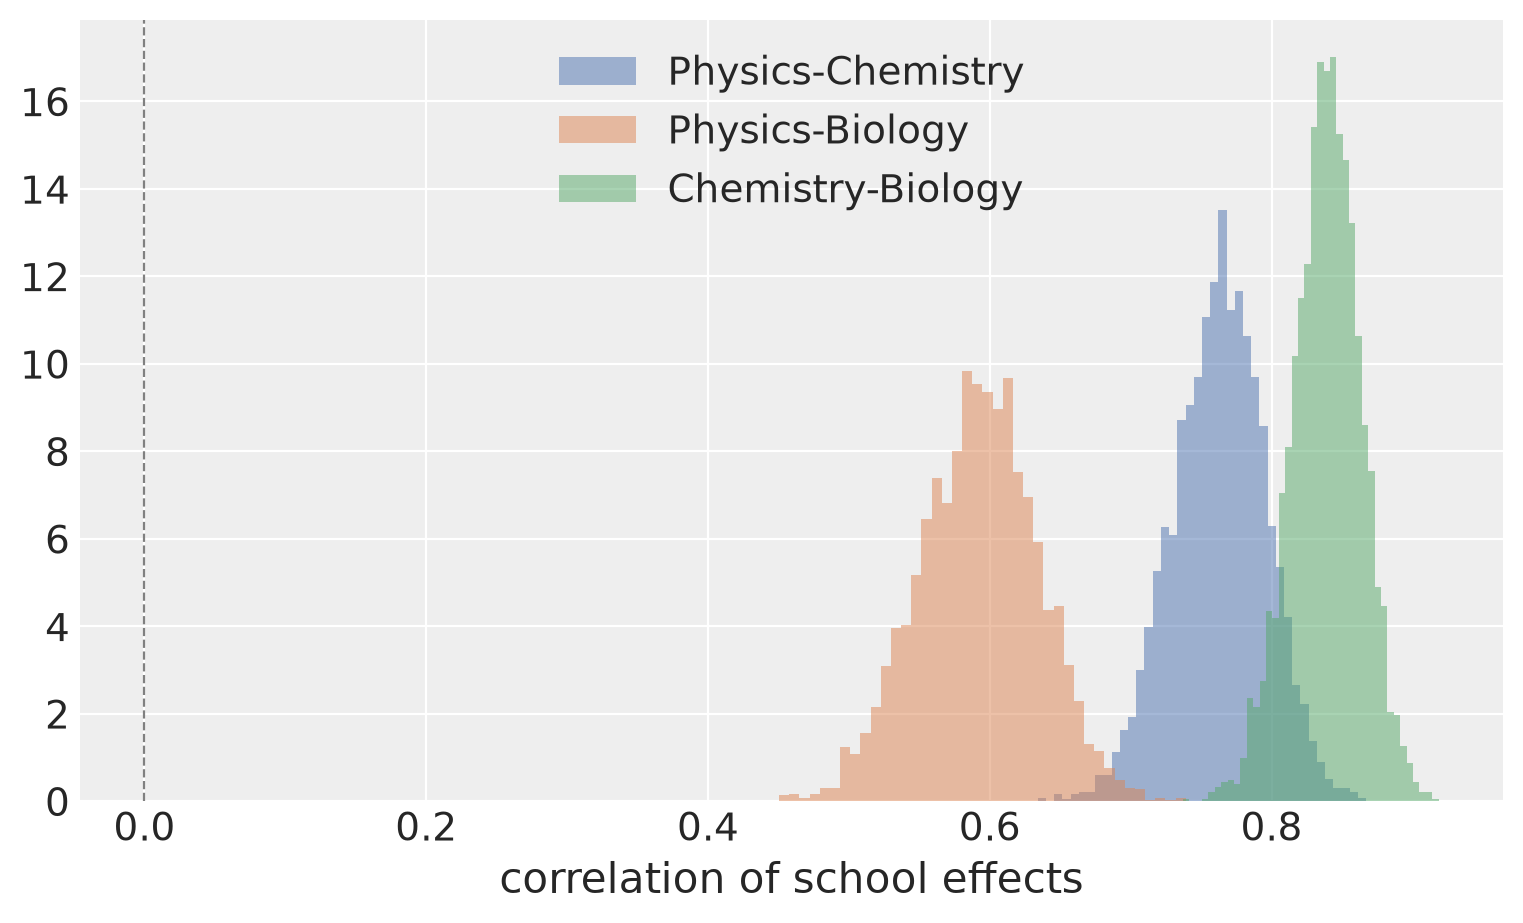

In [9]:
post = idata_corr.posterior
corr_s = post["chol_cov_corr"].to_numpy()

def summarise(x):
    lo, hi = np.percentile(x, [5.5, 94.5])
    return f"mean={x.mean():.3f}, 89% interval [{lo:.3f}, {hi:.3f}]"

pairs = [(0, 1), (0, 2), (1, 2)]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
pair_colors = ["#4C72B0", "#DD8452", "#55A868"]
for (i, j), c in zip(pairs, pair_colors):
    r = corr_s[..., i, j].ravel()
    ax.hist(r, bins=40, density=True, alpha=0.5, color=c, label=f"{subjects[i]}-{subjects[j]}")
    print(f"{subjects[i]}-{subjects[j]:10s} {summarise(r)}")
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("correlation of school effects")
ax.legend()
plt.show()

### Slopes by subject

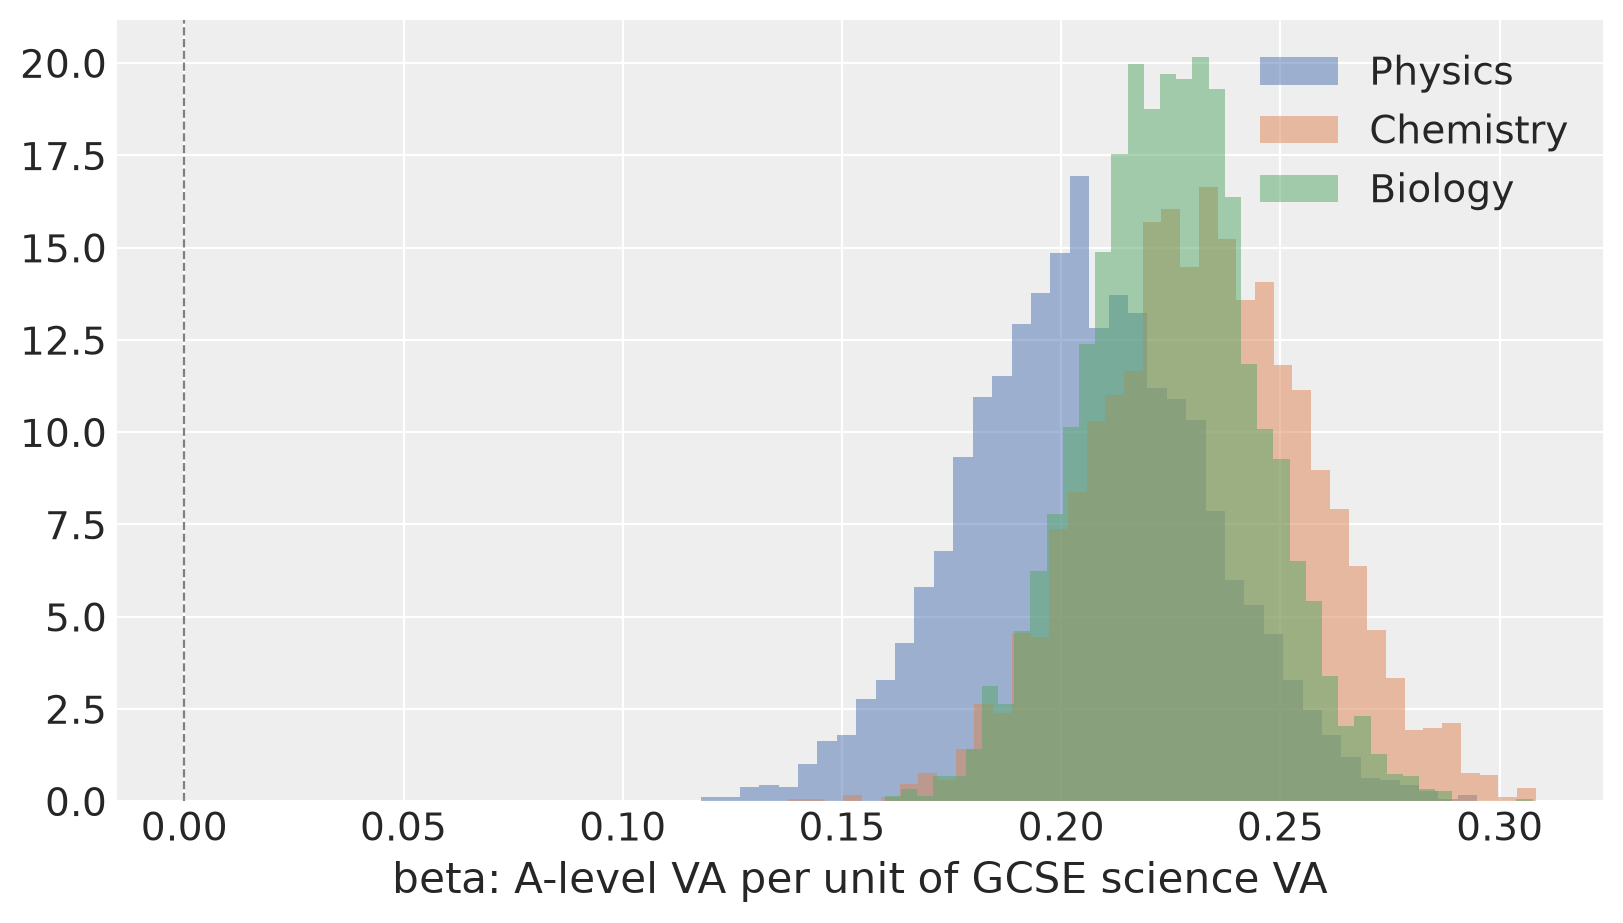

beta Physics    mean=0.205, 89% interval [0.162, 0.250]
beta Chemistry  mean=0.233, 89% interval [0.193, 0.273]
beta Biology    mean=0.225, 89% interval [0.194, 0.257]


In [10]:
beta_post = post["beta"]

fig, ax = plt.subplots(figsize=(8, 4.5))
for subject in subjects:
    ax.hist(beta_post.sel(subject=subject).to_numpy().ravel(), bins=40, density=True, alpha=0.5,
            color=colors[subject], label=subject)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("beta: A-level VA per unit of GCSE science VA")
ax.legend()
plt.show()

for subject in subjects:
    print(f"beta {subject:10s}", summarise(beta_post.sel(subject=subject).to_numpy().ravel()))

## Goodness of fit

Bayesian $R^2$ on the latent scale, per subject: the variance of the structural part $\alpha_s + \beta_s x_i$ relative to that variance plus the residual variance $\tau_s^2$.

In [11]:
x_post = post["mu_x"].to_numpy()[..., None] + post["tau_x"].to_numpy()[..., None] * post["x_raw"].to_numpy()
stds_post = post["chol_cov_stds"].to_numpy()
r2 = {}
for k, name in enumerate(subjects):
    sch = s_idx[subj_idx == k]
    fit = post["alpha"].sel(subject=name).to_numpy()[..., None] + post["beta"].sel(subject=name).to_numpy()[..., None] * x_post[..., sch]
    var_fit = fit.var(axis=-1)
    r2[name] = (var_fit / (var_fit + stds_post[..., k] ** 2)).ravel()
    print(f"{name}: R² from GCSE science VA: {summarise(r2[name])}")

Physics: R² from GCSE science VA: mean=0.079, 89% interval [0.049, 0.111]
Chemistry: R² from GCSE science VA: mean=0.090, 89% interval [0.062, 0.120]


Biology: R² from GCSE science VA: mean=0.135, 89% interval [0.102, 0.170]


### Residual vs. GCSE value-added

Standardised residuals, binned over GCSE science VA, for each subject. Flat near zero means the linear relationship is adequate.

/tmp/ipykernel_103503/1792878149.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


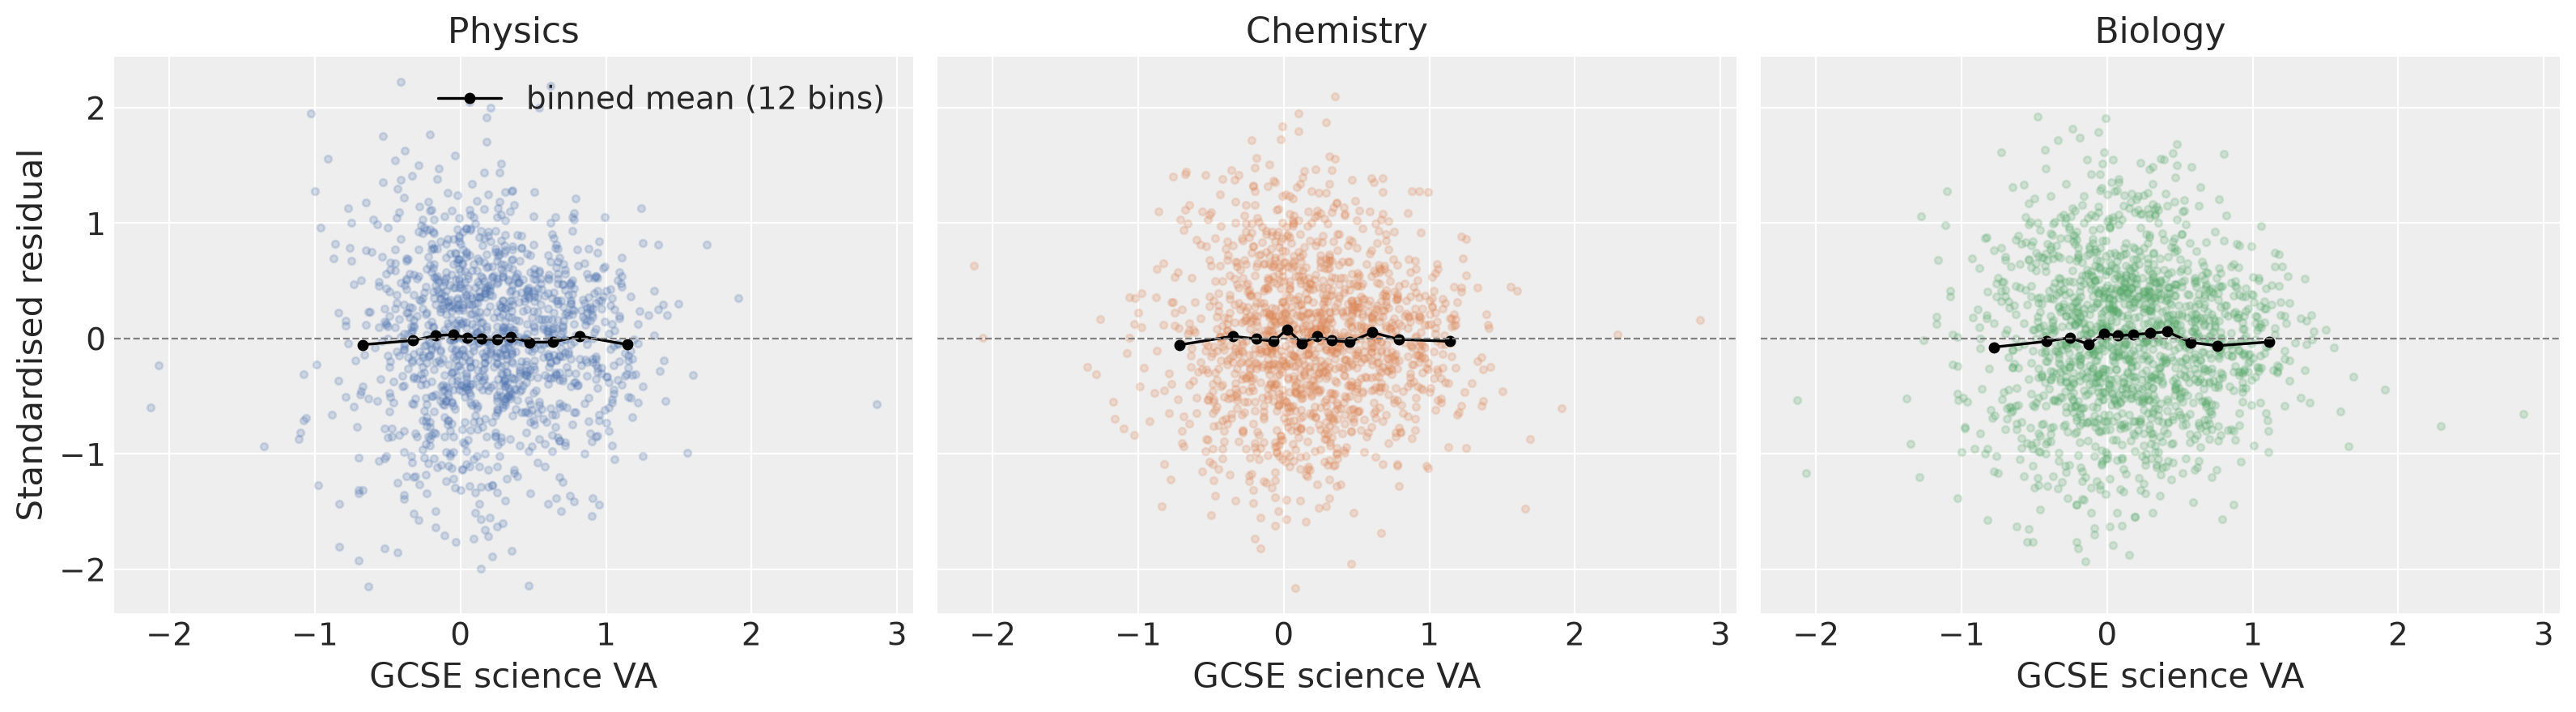

In [12]:
n_obs = len(long)
pred = idata_corr.posterior_predictive["alevel_obs"].to_numpy().reshape(-1, n_obs)
long["std_resid"] = (y_obs - pred.mean(axis=0)) / pred.std(axis=0)
long = long.merge(schools[["URN", "gcse_va"]], on="URN", how="left")
del pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, subject in zip(axes, subjects):
    g = long[long["subject"] == subject]
    binned = g.groupby(pd.qcut(g["gcse_va"], 12), observed=True).agg(gcse_va=("gcse_va", "mean"), r=("std_resid", "mean"))
    ax.scatter(g["gcse_va"], g["std_resid"], color=colors[subject], alpha=0.2, s=10)
    ax.plot(binned["gcse_va"], binned["r"], color="black", marker="o", markersize=4, linewidth=1.2, label="binned mean (12 bins)")
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_title(subject)
    ax.set_xlabel("GCSE science VA")
axes[0].set_ylabel("Standardised residual")
axes[0].legend()
plt.tight_layout()
plt.show()

### Do the strongest GCSE schools "top out"?

Mean A-level VA by GCSE science VA quintile, for each subject.

subject,Physics,Chemistry,Biology
gcse_quintile,,,
1,-0.222,-0.258,-0.234
2,-0.093,-0.109,-0.117
3,-0.068,-0.082,-0.049
4,-0.030,-0.023,0.034
5,0.027,0.039,0.068


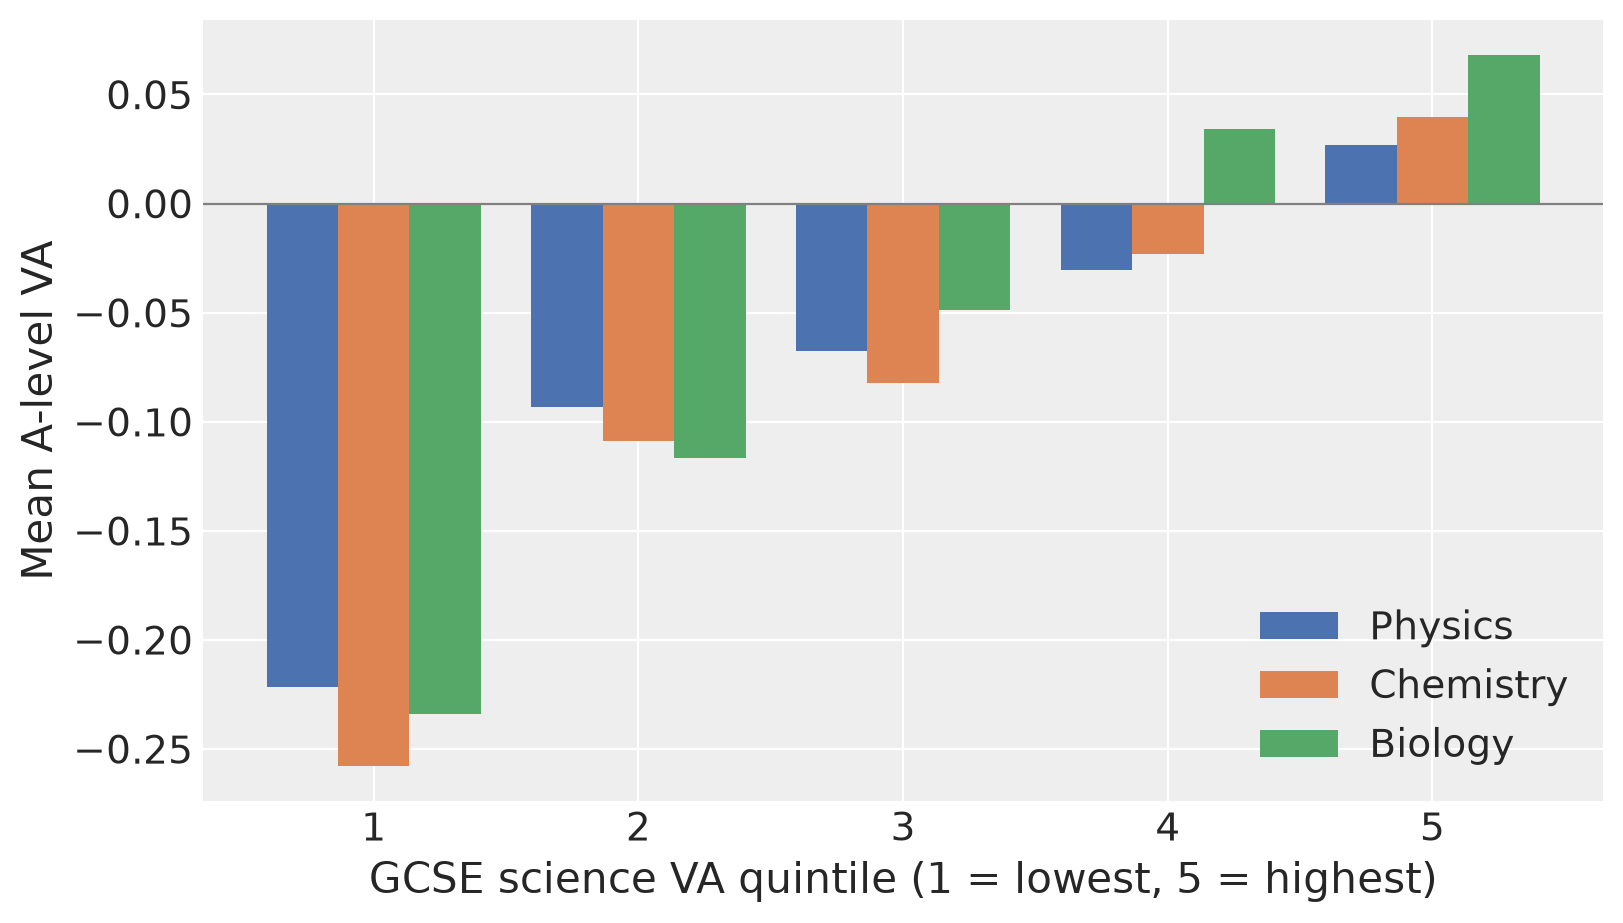

In [13]:
quint = []
for subject, g in long.groupby("subject"):
    t = g.groupby(pd.qcut(g["gcse_va"], 5, labels=range(1, 6)), observed=True).agg(
        mean_alevel_va=("alevel_va", "mean"), n=("URN", "count"))
    t["subject"] = subject
    quint.append(t)
quintile_table = pd.concat(quint).reset_index().rename(columns={"gcse_va": "gcse_quintile"})
display(quintile_table.pivot(index="gcse_quintile", columns="subject", values="mean_alevel_va")[subjects].round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
width = 0.27
for k, subject in enumerate(subjects):
    t = quintile_table[quintile_table["subject"] == subject]
    ax.bar(t["gcse_quintile"].astype(int) + (k - 1) * width, t["mean_alevel_va"], width, color=colors[subject], label=subject)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xlabel("GCSE science VA quintile (1 = lowest, 5 = highest)")
ax.set_ylabel("Mean A-level VA")
ax.legend()
plt.show()

## Interpretation

- **The three sciences respond to GCSE science VA in a similar way.** The slopes are 0.21 (Physics), 0.23 (Chemistry) and 0.23 (Biology), with overlapping intervals, close to the Maths and English Literature slopes. GCSE science VA explains only 8–14% of the variance in true A-level VA (Physics 0.08, Chemistry 0.09, Biology 0.14), so it is a real but modest predictor, as in the other subjects.
- **A school's effects across the sciences are strongly correlated.** After removing the GCSE effect, the correlation between true school effects is 0.84 for Chemistry-Biology (89% interval 0.80–0.88), 0.76 for Physics-Chemistry (0.71–0.81) and 0.59 for Physics-Biology (0.53–0.66). This is very different from English Language and Literature, where the correlation was only about 0.19. A school that does unusually well in one A-level science, given its GCSE science VA, tends to do well in the others: there is a substantial shared school-level science effect that GCSE science VA does not capture. Physics is the least aligned with Biology, and Chemistry sits in between.
- **This is where pooling should pay off most.** With correlations this high, a school's Chemistry result is informative about its Physics and Biology results, which matters for the many schools with small cohorts in one subject.
- **No topping out.** Mean A-level VA rises across GCSE quintiles in all three subjects (from about -0.23 to about +0.03–0.07). The residual plots stay close to zero across the range.
- **Caveats.** A-level cohorts are small (median 13–18 entries), this is a single year of data, and the correlations describe association between subjects within a school, not its cause (a common sixth-form policy, staffing, or the intake could all produce it). Sampling was clean (0 divergences, r_hat ≤ 1.01).

The shared-school-effect model that follows was fitted after seeing these results.

## A shared school effect (one-factor model)

The correlated-residuals model estimates the correlations directly. The more complex alternative gives each school a single latent **science effect** $u_i$ that lifts or lowers all three subjects, and lets the remaining subject-specific noise be independent:

$$
\begin{aligned}
u_i &\sim \text{Normal}(0, 1) \\
y_{is} &= \alpha_s + \beta_s x_i + \lambda_s u_i + \epsilon_{is}, \qquad \epsilon_{is} \sim \text{Normal}(0, \tau_s), \qquad y_{is}^{obs} \sim \text{Normal}(y_{is}, \sigma^y_{is})
\end{aligned}
$$

$\lambda_s > 0$ is how strongly subject $s$ loads on the shared effect (fixing the scale of $u_i$ at 1 and the sign by constraining $\lambda_s$ positive). This is a one-factor model. It implies a correlation between subjects $s$ and $t$ of $\lambda_s\lambda_t / \sqrt{(\lambda_s^2+\tau_s^2)(\lambda_t^2+\tau_t^2)}$, so it is a more restrictive structure than a free correlation matrix, but it gives each school an explicit shared effect $u_i$ that we can look at.

For English this model was not identifiable, because with two subjects and many single-subject schools the shared effect cannot be separated from the residual. Here 1,142 of 1,636 schools have all three subjects. We also **marginalise out** the subject-specific noise $\epsilon_{is}$ analytically: given $u_i$, $y_{is}^{obs} \sim \text{Normal}(\alpha_s + \beta_s x_i + \lambda_s u_i,\ \sqrt{\tau_s^2 + (\sigma^y_{is})^2})$. That removes a latent parameter per observation, which is what made the earlier version sample badly.

In [14]:
with pm.Model(coords={"subject": subjects}) as factor_model:
    mu_x = pm.Normal("mu_x", 0, 1)
    tau_x = pm.HalfNormal("tau_x", 1)
    x_raw = pm.Normal("x_raw", 0, 1, shape=n_schools)
    x_true = mu_x + tau_x * x_raw

    alpha = pm.Normal("alpha", 0, 1, dims="subject")
    beta = pm.Normal("beta", 0, 1, dims="subject")
    lam = pm.HalfNormal("lam", 0.5, dims="subject")
    tau_y = pm.HalfNormal("tau_y", 1, dims="subject")
    u = pm.Normal("u", 0, 1, shape=n_schools)

    mean = alpha[subj_idx] + beta[subj_idx] * x_true[s_idx] + lam[subj_idx] * u[s_idx]
    total_sd = pt.sqrt(tau_y[subj_idx] ** 2 + y_se**2)

    pm.Normal("gcse_obs", mu=x_true, sigma=gcse_se, observed=gcse_obs)
    pm.Normal("alevel_obs", mu=mean, sigma=total_sd, observed=y_obs)

with factor_model:
    idata_factor = pm.sample(draws=1000, tune=2000, chains=4, target_accept=0.99,
                             random_seed=RANDOM_SEED, progressbar=False)

NUTS[nutpie]: [mu_x, tau_x, x_raw, alpha, beta, lam, tau_y, u]


In [15]:
print(f"divergences = {int(idata_factor.sample_stats['diverging'].sum())}")
az.summary(idata_factor, var_names=["alpha", "beta", "lam", "tau_y", "mu_x", "tau_x"], round_to=3)

divergences = 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha[Physics],-0.132,0.015,-0.155,-0.109,1740.873,1882.056,1.000,0.000,0.000
alpha[Chemistry],-0.141,0.013,-0.162,-0.120,985.492,1431.256,1.001,0.000,0.000
alpha[Biology],-0.091,0.010,-0.108,-0.075,1443.310,2167.173,1.001,0.000,0.000
beta[Physics],0.205,0.026,0.164,0.247,1244.884,1901.083,1.002,0.001,0.000
beta[Chemistry],0.232,0.024,0.193,0.272,651.528,1057.116,1.006,0.001,0.001
beta[Biology],0.225,0.019,0.195,0.257,978.215,1720.459,1.003,0.001,0.000
lam[Physics],0.258,0.015,0.235,0.283,1960.507,2427.915,1.000,0.000,0.000
lam[Chemistry],0.361,0.011,0.343,0.379,1130.730,1749.712,1.004,0.000,0.000
lam[Biology],0.239,0.011,0.222,0.256,1273.215,2045.957,1.003,0.000,0.000
tau_y[Physics],0.221,0.015,0.197,0.244,2418.072,2786.099,1.001,0.000,0.000


### Does it agree with the correlated-residuals model?

The one-factor model implies a correlation between each pair of subjects. We compare it with the correlations the free correlation matrix estimated, and with the slopes.

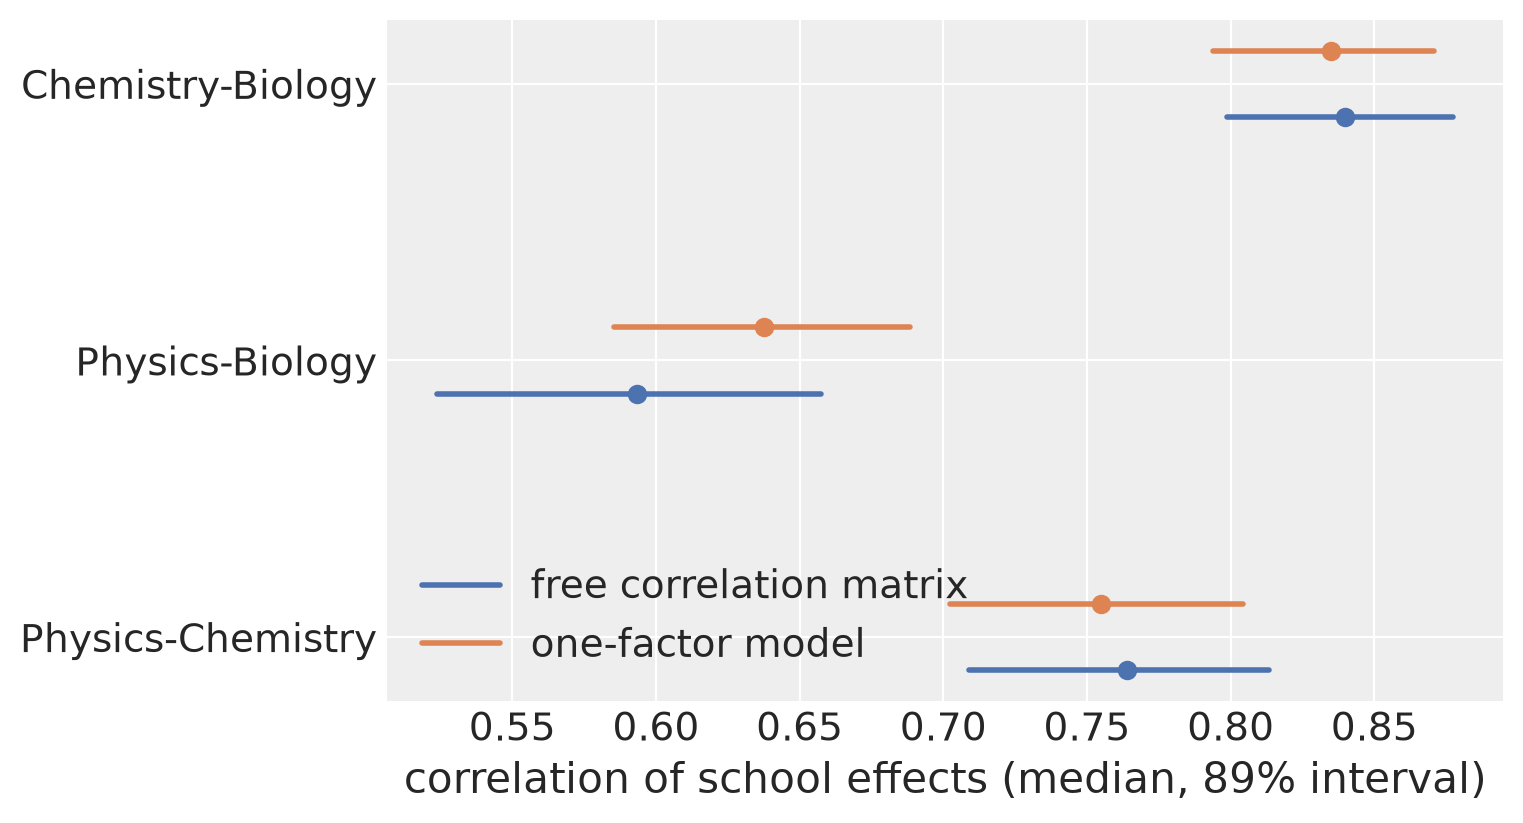

Physics-Chemistry  free: mean=0.763, 89% interval [0.709, 0.813]
                   factor: mean=0.754, 89% interval [0.702, 0.804]
Physics-Biology    free: mean=0.592, 89% interval [0.524, 0.657]
                   factor: mean=0.638, 89% interval [0.585, 0.688]
Chemistry-Biology  free: mean=0.839, 89% interval [0.799, 0.877]
                   factor: mean=0.834, 89% interval [0.794, 0.871]

beta Physics    corr model: mean=0.205, 89% interval [0.162, 0.250]   factor model: mean=0.205, 89% interval [0.164, 0.247]
beta Chemistry  corr model: mean=0.233, 89% interval [0.193, 0.273]   factor model: mean=0.232, 89% interval [0.193, 0.272]
beta Biology    corr model: mean=0.225, 89% interval [0.194, 0.257]   factor model: mean=0.225, 89% interval [0.195, 0.257]


In [16]:
pf = idata_factor.posterior
lam_s = pf["lam"].to_numpy()
tau_s = pf["tau_y"].to_numpy()

pair_names, implied, free = [], {}, {}
for i, j in pairs:
    name = f"{subjects[i]}-{subjects[j]}"
    pair_names.append(name)
    implied[name] = (lam_s[..., i] * lam_s[..., j] / np.sqrt((lam_s[..., i]**2 + tau_s[..., i]**2) * (lam_s[..., j]**2 + tau_s[..., j]**2))).ravel()
    free[name] = corr_s[..., i, j].ravel()

fig, ax = plt.subplots(figsize=(7.5, 4))
for k, name in enumerate(pair_names):
    for off, d, c, lab in [(-0.12, free[name], "#4C72B0", "free correlation matrix"), (0.12, implied[name], "#DD8452", "one-factor model")]:
        lo, m, hi = np.percentile(d, [5.5, 50, 94.5])
        ax.plot([lo, hi], [k + off, k + off], color=c, linewidth=2, label=lab if k == 0 else None)
        ax.plot(m, k + off, "o", color=c)
ax.set_yticks(range(3), pair_names)
ax.set_xlabel("correlation of school effects (median, 89% interval)")
ax.legend(loc="lower left")
plt.show()

for name in pair_names:
    print(f"{name:18s} free: {summarise(free[name])}\n{'':18s} factor: {summarise(implied[name])}")
print()
for k, s in enumerate(subjects):
    print(f"beta {s:10s} corr model: {summarise(post['beta'].sel(subject=s).to_numpy().ravel())}   factor model: {summarise(pf['beta'].sel(subject=s).to_numpy().ravel())}")

### How much of each subject is the shared effect?

The share of each subject's residual variance (after GCSE) that is the shared school effect, $\lambda_s^2/(\lambda_s^2+\tau_s^2)$, and the Bayesian $R^2$ from GCSE alone and from GCSE plus the shared effect.

In [17]:
xf = pf["mu_x"].to_numpy()[..., None] + pf["tau_x"].to_numpy()[..., None] * pf["x_raw"].to_numpy()
uf = pf["u"].to_numpy()
for k, s in enumerate(subjects):
    sch = s_idx[subj_idx == k]
    l, t = lam_s[..., k], tau_s[..., k]
    fit_gcse = pf["alpha"].sel(subject=s).to_numpy()[..., None] + pf["beta"].sel(subject=s).to_numpy()[..., None] * xf[..., sch]
    var_g = fit_gcse.var(axis=-1)
    var_u = (l[..., None] * uf[..., sch]).var(axis=-1)
    print(f"{s}:")
    print(f"  shared share of residual variance: {summarise((l**2 / (l**2 + t**2)).ravel())}")
    print(f"  R² from GCSE only:                 {summarise((var_g / (var_g + var_u + t**2)).ravel())}")
    print(f"  R² from GCSE + shared effect:      {summarise(((var_g + var_u) / (var_g + var_u + t**2)).ravel())}")

Physics:
  shared share of residual variance: mean=0.577, 89% interval [0.502, 0.654]
  R² from GCSE only:                 mean=0.081, 89% interval [0.052, 0.114]
  R² from GCSE + shared effect:      mean=0.597, 89% interval [0.526, 0.669]
Chemistry:
  shared share of residual variance: mean=0.986, 89% interval [0.950, 1.000]
  R² from GCSE only:                 mean=0.090, 89% interval [0.063, 0.120]
  R² from GCSE + shared effect:      mean=0.987, 89% interval [0.955, 1.000]


Biology:
  shared share of residual variance: mean=0.706, 89% interval [0.639, 0.770]
  R² from GCSE only:                 mean=0.135, 89% interval [0.103, 0.171]
  R² from GCSE + shared effect:      mean=0.744, 89% interval [0.686, 0.801]


### Pooling in action

How well is each school's shared effect $u_i$ pinned down, as a function of how many of the three subjects the school has? Schools with more subjects give more information about $u_i$.

,mean,count
n_subjects,,
1,0.853,162
2,0.664,332
3,0.501,1142


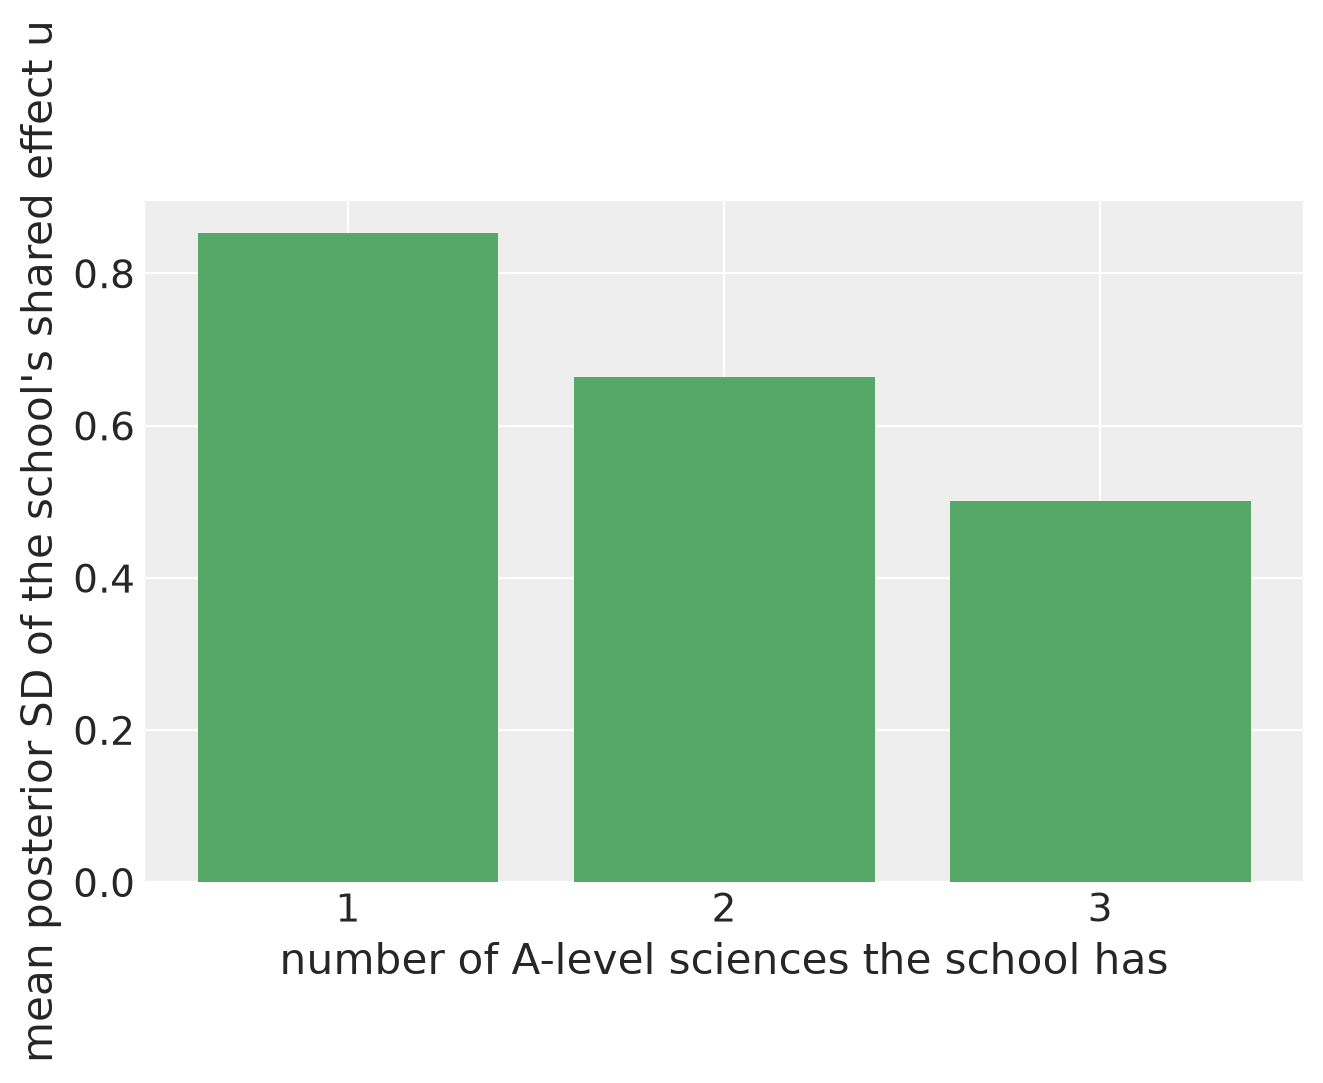

In [18]:
n_sub = long.groupby("school_idx")["subject"].nunique().reindex(range(n_schools)).to_numpy()
u_sd = uf.reshape(-1, n_schools).std(axis=0)
summary = pd.DataFrame({"n_subjects": n_sub, "posterior_sd_u": u_sd}).groupby("n_subjects")["posterior_sd_u"].agg(["mean", "count"]).round(3)
display(summary)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(summary.index.astype(int), summary["mean"], color="#55A868")
ax.set_xticks([1, 2, 3])
ax.set_xlabel("number of A-level sciences the school has")
ax.set_ylabel("mean posterior SD of the school's shared effect u")
plt.show()

## Interpretation of the shared-effect model

- **It is identifiable and samples cleanly here, unlike for English.** 0 divergences, r_hat ≤ 1.02. With three subjects and 70% of schools having all three, the shared effect can be separated from subject-specific noise, and marginalising the subject-specific noise removed the sampling problems.
- **It agrees with the correlated-residuals model.** The slopes are identical to two decimal places (Physics 0.21, Chemistry 0.23, Biology 0.23), so those conclusions do not depend on how the cross-subject dependence is modelled. The correlations implied by the one-factor structure (Physics-Chemistry 0.75, Physics-Biology 0.64, Chemistry-Biology 0.83) are close to the freely estimated ones (0.76, 0.59, 0.84), with Physics-Biology the only noticeable difference.
- **One shared effect accounts for most of the school-to-school variation left after GCSE.** It makes up about 58% of Physics's residual variance, 71% of Biology's, and almost all of Chemistry's (99%, with subject-specific SD of only 0.035). GCSE science VA alone explains 8–14%. So a school's general strength in A-level science matters far more than its GCSE science VA for how it does in any one science.
- **Caveats.** (1) Chemistry's subject-specific variance sits against zero (89% interval 0.003–0.081): the shared effect is effectively defined by Chemistry, so the individual loadings should not be over-read. With only three subjects a one-factor model is just-identified, so it cannot be tested against the free correlation matrix, and the correlated-residuals model remains the more general description. (2) "R² from GCSE + shared effect" is an in-sample description of how much variation the latent school effect absorbs, not variation explained by a measured predictor, so it is not comparable with the R² values from GCSE VA alone. (3) The shared effect is a school-level association across subjects, not a cause: a common sixth-form policy, intake, or staffing could all produce it. (4) PSIS-LOO is not usable for these latent-variable models, so we have not compared predictive accuracy.
- **Pooling helps, but does not pin the effect down.** The posterior SD of a school's shared effect is about 0.85 for schools with one science, 0.66 with two and 0.50 with three, against a prior SD of 1. More subjects means a better-determined school effect, but even with all three it stays fairly uncertain because each score is noisy.

## Regional effects

Does the relationship between GCSE science VA and A-level VA differ by region? We extend the correlated-residuals model so that each subject's intercept and slope vary by region (the 9 English regions, `RGN24NM`), with partial pooling:

$$
\alpha_{sr} = \alpha_s + \sigma_\alpha\, a_{sr}, \qquad \beta_{sr} = \beta_s + \sigma_\beta\, b_{sr}, \qquad a_{sr}, b_{sr} \sim \text{Normal}(0, 1)
$$

The spreads $\sigma_\alpha$ and $\sigma_\beta$ are shared across subjects (with only 9 regions there is little information for separate ones), so the model estimates one typical size of regional difference in baseline A-level VA and one in the slope, while letting each subject's regional pattern differ. Both get a tight `HalfNormal(0.5)` prior. Everything else, including the LKJ correlation of school residuals across subjects, is unchanged.

First, the raw picture: mean GCSE and A-level VA by region and the number of schools.

In [19]:
region_of_school = schools["URN"].map(raw.set_index("URN")["RGN24NM"])
region_idx, region_labels = pd.factorize(region_of_school)
n_regions = len(region_labels)
r_idx = region_idx[s_idx]

raw_by_region = pd.DataFrame({"schools": region_of_school.value_counts(), "mean GCSE VA": schools.groupby(region_of_school)["gcse_va"].mean()})
for subject in subjects:
    g = long[long["subject"] == subject]
    raw_by_region[f"mean A-level {subject} VA"] = g.groupby(g["URN"].map(raw.set_index("URN")["RGN24NM"]))["alevel_va"].mean()
raw_by_region.round(3).sort_values("schools", ascending=False)

,schools,mean GCSE VA,mean A-level Physics VA,mean A-level Chemistry VA,mean A-level Biology VA
URN,,,,,
London,355,0.336,-0.097,-0.102,-0.057
South East,252,0.211,-0.001,-0.090,-0.067
East of England,203,0.083,-0.021,-0.079,-0.014
West Midlands,200,-0.028,-0.268,-0.176,-0.120
East Midlands,161,0.022,-0.096,-0.068,-0.036
South West,159,0.177,0.011,0.016,-0.039
North West,136,0.037,-0.060,-0.072,-0.074
Yorkshire and The Humber,107,0.078,-0.097,0.012,0.005
North East,63,-0.138,-0.148,-0.260,-0.211


In [20]:
with pm.Model(coords={"subject": subjects, "region": region_labels}) as region_model:
    mu_x = pm.Normal("mu_x", 0, 1)
    tau_x = pm.HalfNormal("tau_x", 1)
    x_raw = pm.Normal("x_raw", 0, 1, shape=n_schools)
    x_true = mu_x + tau_x * x_raw

    alpha = pm.Normal("alpha", 0, 1, dims="subject")
    beta = pm.Normal("beta", 0, 1, dims="subject")
    sigma_alpha = pm.HalfNormal("sigma_alpha", 0.5)
    sigma_beta = pm.HalfNormal("sigma_beta", 0.5)
    a_raw = pm.Normal("a_raw", 0, 1, dims=("subject", "region"))
    b_raw = pm.Normal("b_raw", 0, 1, dims=("subject", "region"))
    alpha_sr = pm.Deterministic("alpha_sr", alpha[:, None] + sigma_alpha * a_raw, dims=("subject", "region"))
    beta_sr = pm.Deterministic("beta_sr", beta[:, None] + sigma_beta * b_raw, dims=("subject", "region"))

    chol, corr, stds = pm.LKJCholeskyCov(
        "chol_cov", n=n_subjects, eta=2.0, sd_dist=pm.HalfNormal.dist(1.0, shape=n_subjects), compute_corr=True
    )
    z = pm.Normal("z", 0, 1, shape=(n_schools, n_subjects))
    eps = pt.dot(z, chol.T)[s_idx, subj_idx]

    y_true = alpha_sr[subj_idx, r_idx] + beta_sr[subj_idx, r_idx] * x_true[s_idx] + eps

    pm.Normal("gcse_obs", mu=x_true, sigma=gcse_se, observed=gcse_obs)
    pm.Normal("alevel_obs", mu=y_true, sigma=y_se, observed=y_obs)

with region_model:
    idata_region = pm.sample(draws=1000, tune=2000, chains=4, target_accept=0.99,
                             random_seed=RANDOM_SEED, progressbar=False)

NUTS[nutpie]: [mu_x, tau_x, x_raw, alpha, beta, sigma_alpha, sigma_beta, a_raw, b_raw, chol_cov, z]


In [21]:
print(f"divergences = {int(idata_region.sample_stats['diverging'].sum())}")
az.summary(idata_region, var_names=["sigma_alpha", "sigma_beta", "alpha", "beta", "chol_cov_stds", "mu_x", "tau_x"], round_to=3)

divergences = 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_alpha,0.034,0.014,0.012,0.057,364.208,327.593,1.007,0.001,0.000
sigma_beta,0.030,0.020,0.004,0.065,460.437,902.184,1.006,0.001,0.000
alpha[Physics],-0.129,0.020,-0.161,-0.097,1746.999,2098.127,1.003,0.000,0.000
alpha[Chemistry],-0.138,0.018,-0.167,-0.108,1472.217,1831.413,1.000,0.000,0.000
alpha[Biology],-0.089,0.017,-0.115,-0.064,1299.981,1674.330,1.001,0.000,0.000
beta[Physics],0.204,0.029,0.159,0.253,1555.961,1909.519,1.001,0.001,0.000
beta[Chemistry],0.237,0.028,0.192,0.282,1455.094,2090.725,1.001,0.001,0.001
beta[Biology],0.234,0.023,0.196,0.272,1592.346,2263.550,1.002,0.001,0.000
chol_cov_stds[0],0.334,0.013,0.313,0.354,2123.696,2622.268,1.001,0.000,0.000
chol_cov_stds[1],0.361,0.011,0.343,0.378,2487.512,2847.729,1.001,0.000,0.000


### How big are the regional differences?

The posteriors of the two spreads: `sigma_alpha` (typical regional shift in baseline A-level VA) and `sigma_beta` (typical regional difference in the slope). A spread near zero means regions look alike.

sigma_alpha: mean=0.034, 89% interval [0.012, 0.057]
sigma_beta: mean=0.030, 89% interval [0.004, 0.065]


/tmp/ipykernel_103503/2655007468.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


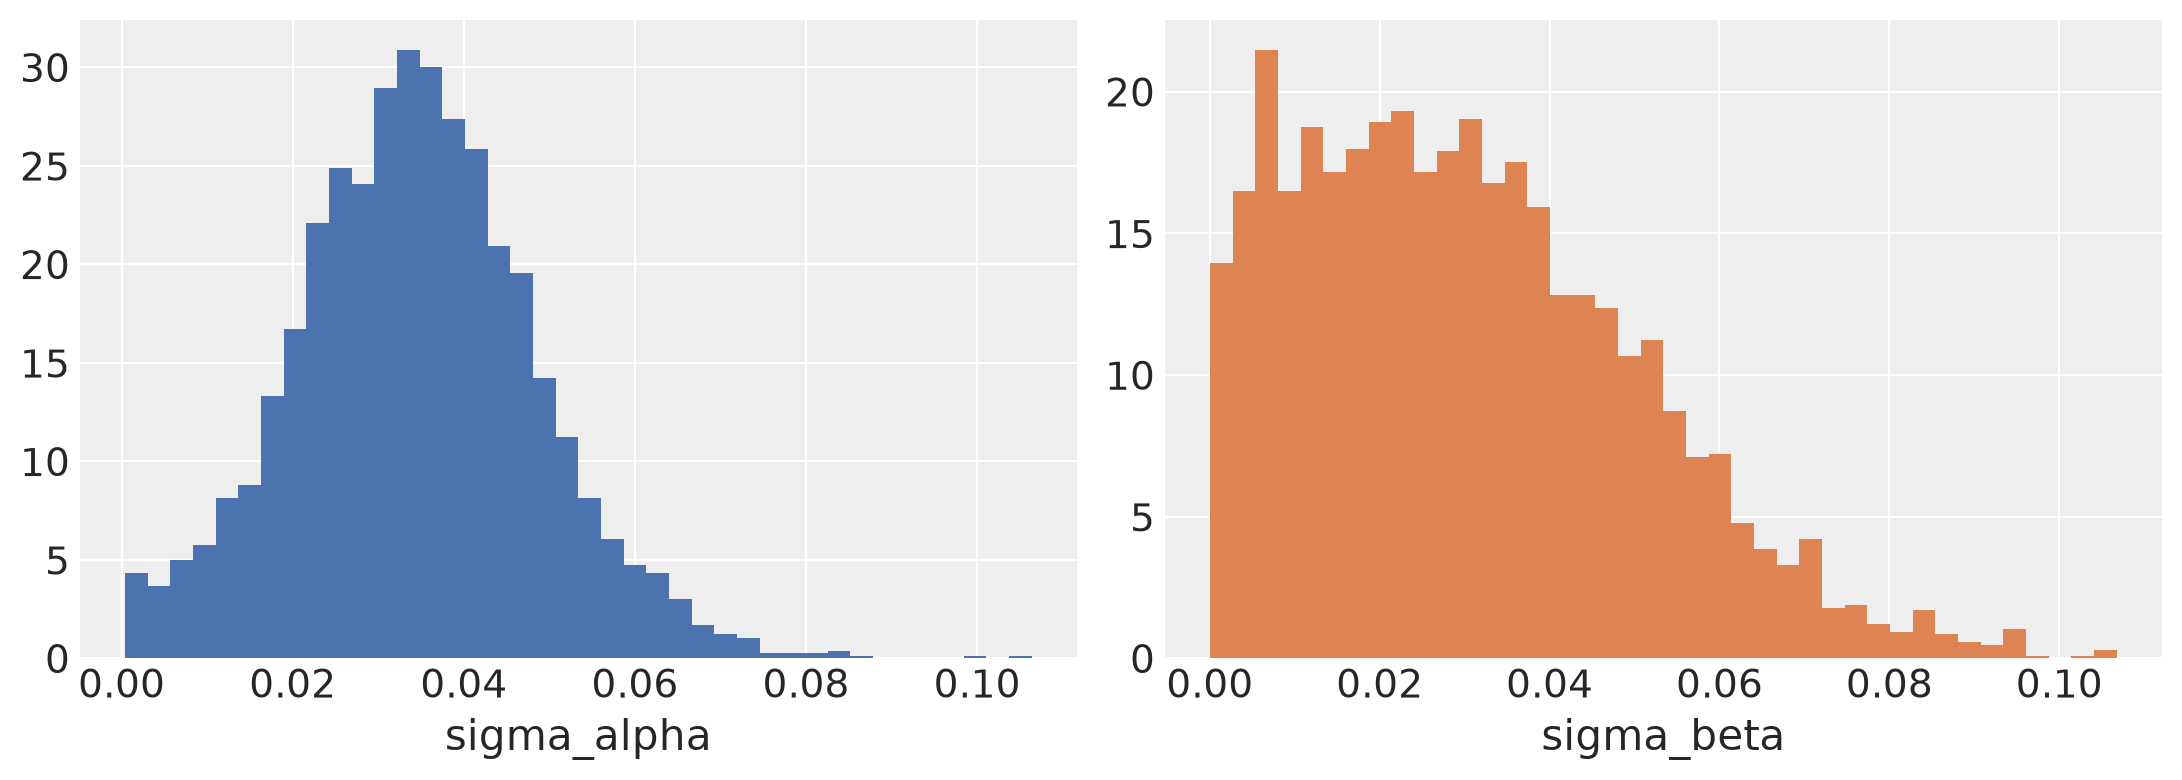

In [22]:
pr = idata_region.posterior
for name in ["sigma_alpha", "sigma_beta"]:
    print(f"{name}: {summarise(pr[name].to_numpy().ravel())}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name, c in zip(axes, ["sigma_alpha", "sigma_beta"], ["#4C72B0", "#DD8452"]):
    ax.hist(pr[name].to_numpy().ravel(), bins=40, density=True, color=c)
    ax.set_xlabel(name)
plt.tight_layout()
plt.show()

### Region by region

For each subject, each region's intercept and slope relative to that subject's average across regions (median and 89% interval). Regions are ordered by number of schools, largest at the top. Intervals that straddle zero mean the region is not distinguishable from the subject's average.

/tmp/ipykernel_103503/2102355965.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


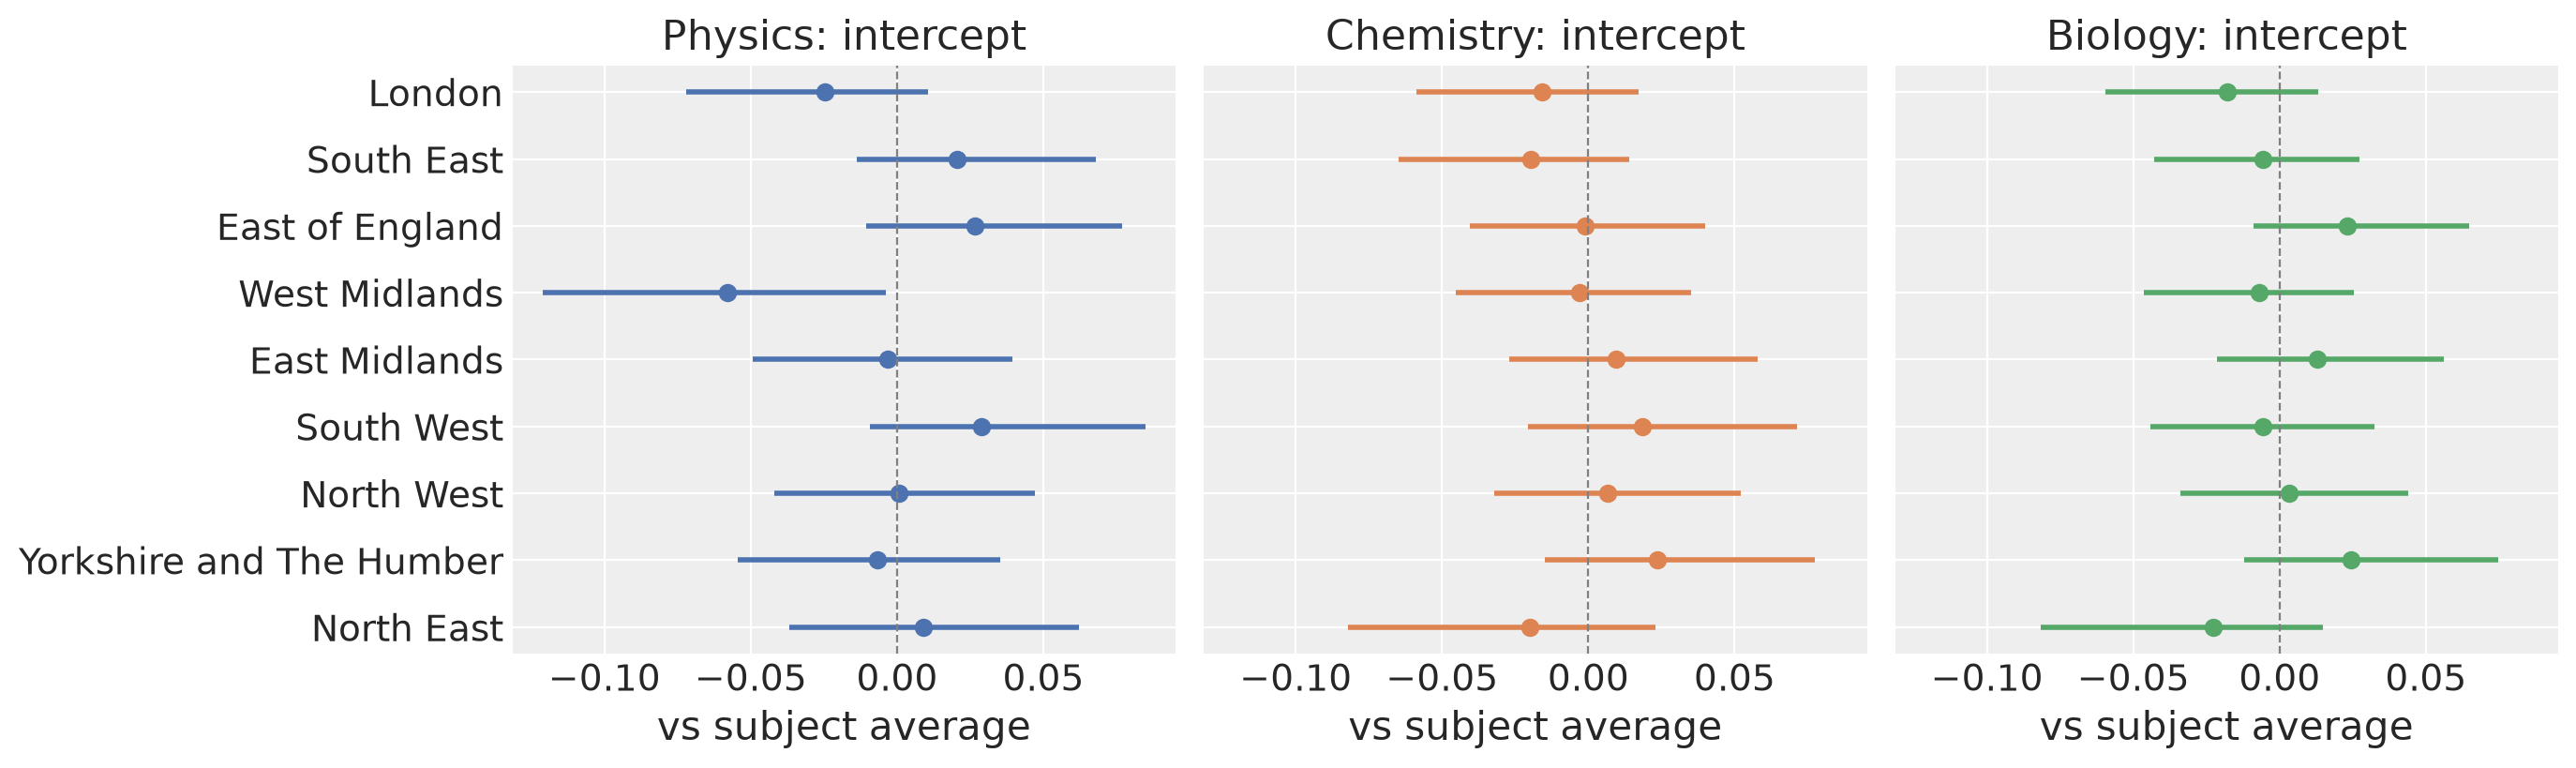

/tmp/ipykernel_103503/2102355965.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


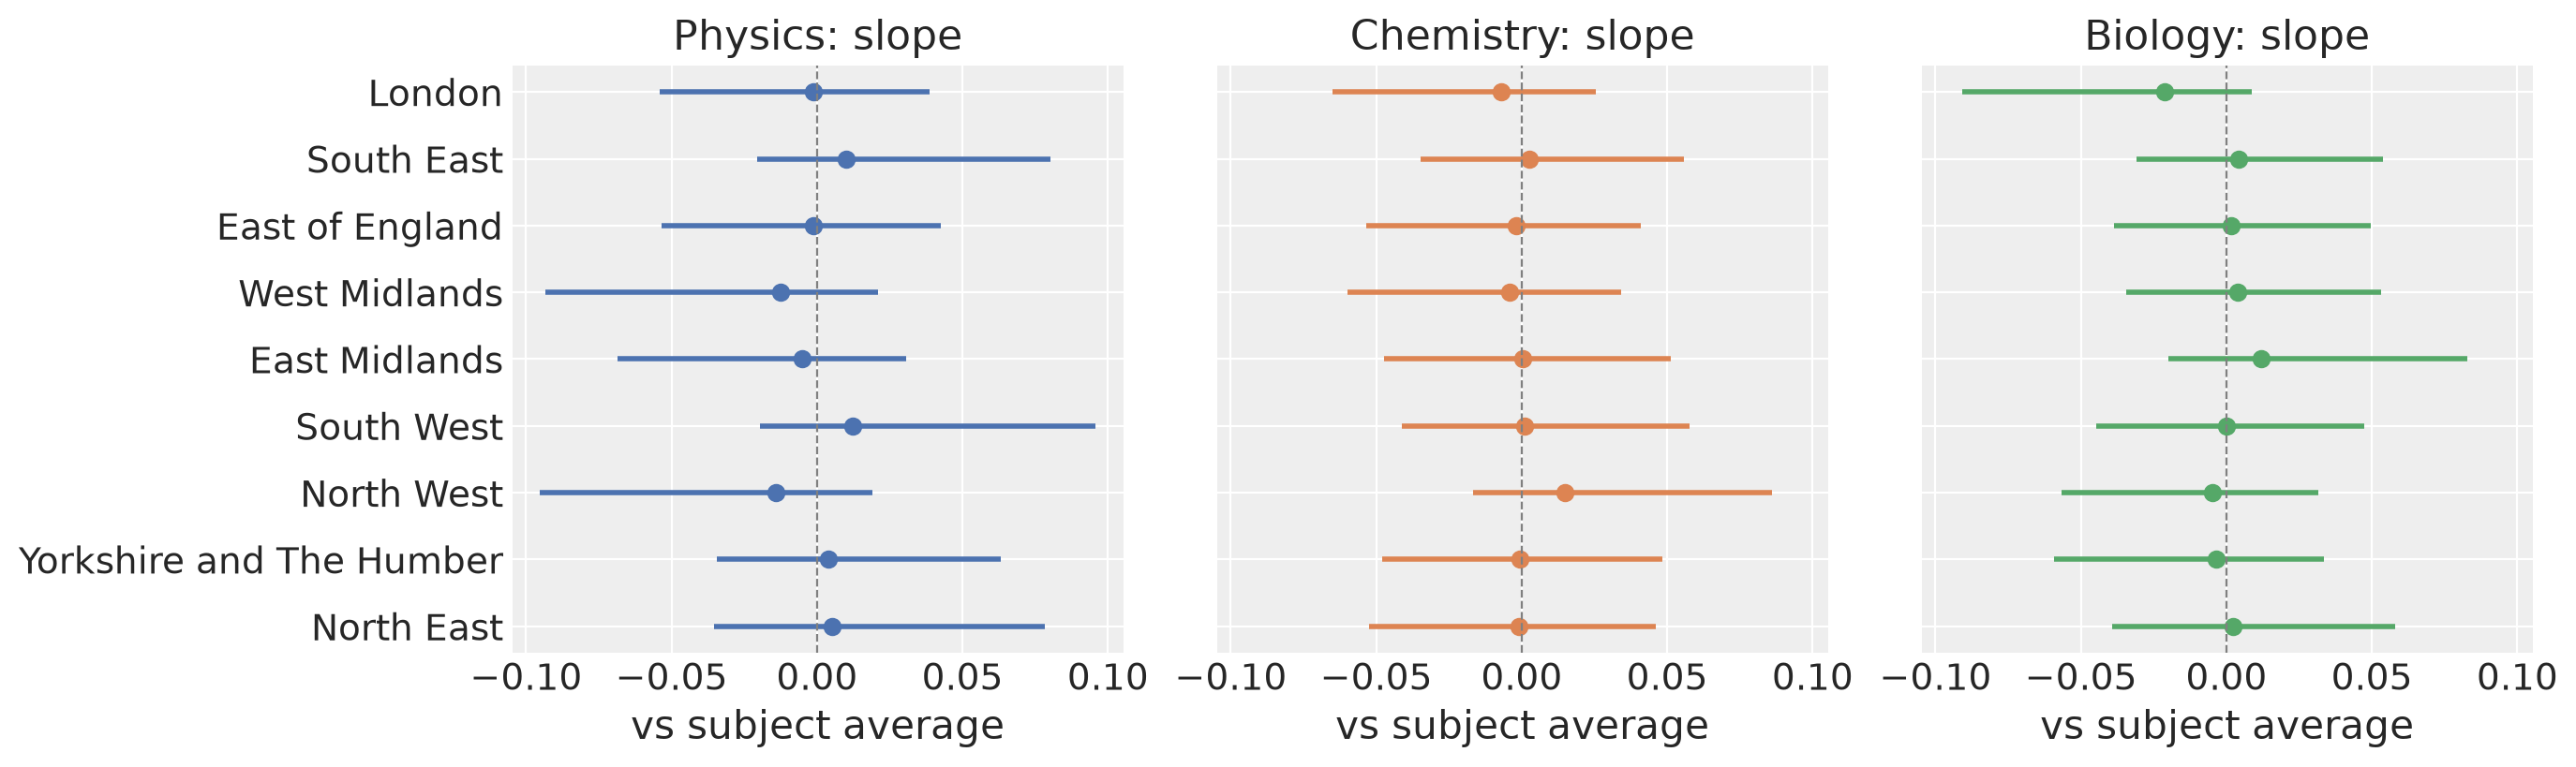

In [23]:
region_order = list(raw_by_region.sort_values("schools", ascending=False).index)
ord_idx = [list(region_labels).index(r) for r in region_order]

def region_deviation_plot(var, base, title):
    dev = (pr[var] - pr[base]).transpose("chain", "draw", "subject", "region").to_numpy()
    fig, axes = plt.subplots(1, n_subjects, figsize=(4.6 * n_subjects, 4.2), sharey=True, sharex=True)
    for k, (ax, subject) in enumerate(zip(np.atleast_1d(axes), subjects)):
        d = dev[:, :, k, :].reshape(-1, n_regions)[:, ord_idx]
        lo, med, hi = np.percentile(d, [5.5, 50, 94.5], axis=0)
        y = np.arange(n_regions)[::-1]
        ax.hlines(y, lo, hi, color=colors[subject], linewidth=2)
        ax.plot(med, y, "o", color=colors[subject])
        ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
        ax.set_title(f"{subject}: {title}")
        ax.set_yticks(y, region_order)
        ax.set_xlabel("vs subject average")
    plt.tight_layout()
    plt.show()

region_deviation_plot("alpha_sr", "alpha", "intercept")
region_deviation_plot("beta_sr", "beta", "slope")

### Does region change the picture?

The subject-level slopes (now the average across regions) and Bayesian $R^2$ with and without regional terms, and the cross-subject correlations.

In [24]:
xr = pr["mu_x"].to_numpy()[..., None] + pr["tau_x"].to_numpy()[..., None] * pr["x_raw"].to_numpy()
a_sr = pr["alpha_sr"].transpose("chain", "draw", "subject", "region").to_numpy()
b_sr = pr["beta_sr"].transpose("chain", "draw", "subject", "region").to_numpy()
stds_r = pr["chol_cov_stds"].to_numpy()
for k, s in enumerate(subjects):
    m = subj_idx == k
    sch, reg = s_idx[m], r_idx[m]
    fit = a_sr[:, :, k, :][..., reg] + b_sr[:, :, k, :][..., reg] * xr[..., sch]
    var_fit = fit.var(axis=-1)
    r2_region = (var_fit / (var_fit + stds_r[..., k] ** 2)).ravel()
    print(f"{s}:")
    print(f"   slope   without region: {summarise(post['beta'].sel(subject=s).to_numpy().ravel())}")
    print(f"   slope   mean over regions: {summarise(pr['beta'].sel(subject=s).to_numpy().ravel())}")
    print(f"   R² without region: {summarise(r2[s])}")
    print(f"   R² with region:    {summarise(r2_region)}")

corr_r = pr["chol_cov_corr"].to_numpy()
print()
for i, j in pairs:
    print(f"corr {subjects[i]}-{subjects[j]}: without region {summarise(corr_s[..., i, j].ravel())}   with region {summarise(corr_r[..., i, j].ravel())}")

Physics:
   slope   without region: mean=0.205, 89% interval [0.162, 0.250]
   slope   mean over regions: mean=0.204, 89% interval [0.159, 0.253]
   R² without region: mean=0.079, 89% interval [0.049, 0.111]
   R² with region:    mean=0.094, 89% interval [0.062, 0.130]
Chemistry:
   slope   without region: mean=0.233, 89% interval [0.193, 0.273]
   slope   mean over regions: mean=0.237, 89% interval [0.192, 0.282]
   R² without region: mean=0.090, 89% interval [0.062, 0.120]
   R² with region:    mean=0.096, 89% interval [0.068, 0.126]


Biology:
   slope   without region: mean=0.225, 89% interval [0.194, 0.257]
   slope   mean over regions: mean=0.234, 89% interval [0.196, 0.272]
   R² without region: mean=0.135, 89% interval [0.102, 0.170]
   R² with region:    mean=0.145, 89% interval [0.111, 0.182]

corr Physics-Chemistry: without region mean=0.763, 89% interval [0.709, 0.813]   with region mean=0.767, 89% interval [0.710, 0.821]
corr Physics-Biology: without region mean=0.592, 89% interval [0.524, 0.657]   with region mean=0.590, 89% interval [0.520, 0.658]
corr Chemistry-Biology: without region mean=0.839, 89% interval [0.799, 0.877]   with region mean=0.838, 89% interval [0.798, 0.878]


## Interpretation of the regional effects

- **Regional differences exist but are small.** The typical regional shift in baseline A-level VA (`sigma_alpha`) is about 0.03 (89% interval 0.01–0.06), which is small next to the residual spread of 0.28–0.36 and to the subject intercepts of about -0.09 to -0.14. The typical regional difference in the slope (`sigma_beta`) is about 0.03 (0.004–0.065), consistent with the slope being essentially the same everywhere. Region does not change how GCSE science VA relates to A-level VA.
- **Almost no individual region stands out.** In the region-by-region plots nearly every interval straddles zero, for both intercepts and slopes and for all three subjects. The clearest case is West Midlands Physics, about 0.06 below the Physics average given its GCSE VA (interval about -0.12 to -0.005). This is one of 54 comparisons, so it is weak evidence on its own.
- **The raw regional pattern is mostly a GCSE pattern.** London has the highest mean GCSE science VA (0.34) but only average A-level VA, while the West Midlands and North East have the lowest of both. Given a school's GCSE VA, the model finds London's A-level VA slightly below what its GCSE VA would predict (about -0.02 in each science, not distinguishable from zero) and the other regions close to average, so we do not see a "London effect" carrying through to A-level.
- **Nothing else moves.** Subject slopes (Physics 0.20, Chemistry 0.24, Biology 0.23) and the cross-subject correlations (Physics-Chemistry 0.77, Physics-Biology 0.59, Chemistry-Biology 0.84) are the same with and without region. Bayesian R² rises only a little (Physics 0.08 to 0.09, Chemistry 0.09 to 0.10, Biology 0.14 to 0.15), so region explains a very small part of the variation that GCSE VA leaves unexplained.
- **Caveats.** Regional spreads are shared across subjects, so the model cannot say whether one subject is more regionally variable than another. Region is a coarse grouping; local authority or school type could show more, but that data is not in this dataset. Sampling was clean (0 divergences, r_hat ≤ 1.02).